### Multiplot for any rho experiment for a timeseries

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import scipy
import sys 
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

In [2]:
datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"congo_basin_evergreen.shp")

dataf ="/Volumes/New_5TB/ESA_F4R/2026_mergeds/" 
datao ="/Volumes/New_5TB/ESA_F4R/2026_rho/bands/" 
datap ="/Volumes/New_5TB/ESA_F4R/2026_plots/bands/precip_filtered/" 
datam ="/Volumes/New_5TB/ESA_F4R/ERA5_monthly/" 

S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_HI" # L_M or L_HI
band = {'EQ_E':[-5,5,18,29],'EQ_W':[-5,5,8,18]}

In [3]:
rho_xarr={}
for B in ['EQ_E','EQ_W']:
    print('running band:', B)
    #rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    rho_xarr[B] = xr.open_dataset(datao+L_NAME+"_"+S_NAME+"_"+B+"_rot_rho_era5_precipfiltered.nc",engine='netcdf4')
    #print(rho_xarr[B])

running band: EQ_E
running band: EQ_W


In [ ]:
#Individual year-month plots - average rotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=12
nrows=35
h = nrows
w = ncols
cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for B in ['EQ_E','EQ_W']:
    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(15,24))
    
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()
    
    RHO = rho_xarr[B]['rho'].mean('rot')
    mtime = RHO['time']
    ap = 0.9*len(RHO.lon.values) / len(RHO.lat.values)
    
    #Loop over all of the models
    for i,T in enumerate(mtime):
    
            # Select the week 1 forecast from the specified model
            data=RHO.sel(time=T)
    
            # Contour plot
            cs=axs[i].pcolormesh(RHO['lon'].values,RHO['lat'].values,
                               data.values,
                               vmin=0.0,vmax=0.8,
                               #levels=13,
                               #extend='max',
                               cmap=cmap,
                               #aspect= ap,
                               rasterized=True,
                               transform = ccrs.PlateCarree())
    
            # Title each subplot with the name of the model
            axs[i].set_title(str(data["time.year"].values)+"-"+str("{:02d}".format(data["time.month"].values)),
                     fontsize=4)
    
            # Draw the coastines for each subplot
            axs[i].coastlines()
            axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    
    # Adjust the location of the subplots on the page to make room for the colorbar
    fig.subplots_adjust(hspace=0,wspace=-0.5)
    #plt.tight_layout()
    
    # Add a colorbar axis at the bottom of the graph
    #cbar_ax = fig.add_axes([0.2, 0.001, 0.6, 0.02])

    # Draw the colorbar
    #cbar=fig.colorbar(cs,ax=cbar_ax,extend='both')#,shrink=0.5)
    cbar = fig.colorbar(cs, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.2,extend="both",fraction=0.2)
    
    # Add a big title at the top
    plt.suptitle("$\\rho$ "+B+" Band "+L_NAME+" "+S_NAME, fontsize=10,y=1.01,x=0.5)
    plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_rotmean.png",bbox_inches="tight",dpi=200)
    plt.show()
    plt.clf()
        

KeyboardInterrupt: 

In [ ]:
#Individual year-month plots - per rotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=12
nrows=35
h = nrows
w = ncols
cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for B in ['EQ_E','EQ_W']:
    for r in np.arange(1,5):

        # Define the figure and each axis for the 3 rows and 3 columns
        fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                                subplot_kw={'projection': ccrs.PlateCarree()},
                                gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                                layout="constrained",
                                figsize=(15,24))
        
        # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
        axs=axs.flatten()
        
        RHO = rho_xarr[B]['rho'].sel(rot=r)
        mtime = RHO['time']
        ap = 0.9*len(RHO.lon.values) / len(RHO.lat.values)
        
        #Loop over all of the models
        for i,T in enumerate(mtime):
        
                # Select the week 1 forecast from the specified model
                data=RHO.sel(time=T)
        
                # Contour plot
                cs=axs[i].pcolormesh(RHO['lon'].values,RHO['lat'].values,
                                   data.values,
                                   vmin=0.0,vmax=0.8,
                                   #levels=13,
                                   #extend='max',
                                   cmap=cmap,
                                   #aspect= ap,
                                   rasterized=True,
                                   transform = ccrs.PlateCarree())
        
                # Title each subplot with the name of the model
                axs[i].set_title(str(data["time.year"].values)+"-"+str("{:02d}".format(data["time.month"].values)),
                         fontsize=4)
        
                # Draw the coastines for each subplot
                axs[i].coastlines()
                axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
        
        # Adjust the location of the subplots on the page to make room for the colorbar
        fig.subplots_adjust(hspace=0,wspace=-0.5)
        #plt.tight_layout()
        
        # Add a colorbar axis at the bottom of the graph
        #cbar_ax = fig.add_axes([0.2, 0.001, 0.6, 0.02])

        # Draw the colorbar
        #cbar=fig.colorbar(cs,ax=cbar_ax,extend='both')#,shrink=0.5)
        cbar = fig.colorbar(cs, ax=axs, orientation='horizontal',
                            #location="bottom",
                            shrink=0.2,extend="both",fraction=0.2)
        
        # Add a big title at the top
        plt.suptitle("$\\rho$ "+B+" Band "+L_NAME+" "+S_NAME+" (rot:"+str(r)+")", fontsize=10,y=1.01,x=0.5)
        plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_rot_"+str(r)+".png",bbox_inches="tight",dpi=200)
        plt.show()
        plt.clf()
        

In [ ]:
##Filtering out outliers for plotting 
#for B in ['N','S','EQ']:
#    for r in np.arange(1,5):
#        print("*** Rotation is: ",r)
#        try:
#            print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
#            print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
#            rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<=1.0,1.0)
#            rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>0.0,0.0)
#            print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
#            print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
#            print('-------------------------')
#        except:
#            print('No outliers')
#            print(rho_xarr[B])

##Filtering out outliers for plotting 
#for B in ['N','S','EQ']:
#    for r in np.arange(1,5):
#        print("*** Rotation is: ",r)
#        try:
#            print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
#            print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
#            rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<=1.0,np.nan)
#            rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>0.0,np.nan)
#            print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
#            print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
#            print('-------------------------')
#        except:
#            print('No outliers')
#            print(rho_xarr[B])

In [ ]:
#Monthly average plots - per rotation
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for B in ['EQ_E','EQ_W']:
    for M in range(1,13):
        for r in np.arange(1,5):
            rho_plot = rho_xarr[B]['rho'][r-1,:,:,:] 
            month_rho = rho_plot.where(rho_plot['time.month']==M,drop=True).mean('time')
            fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
            ax.coastlines()
            ax.add_feature(cartopy.feature.BORDERS)
            ax.add_feature(cartopy.feature.RIVERS)
            ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
            cmap=plt.cm.viridis
            cmap.set_extremes(over='orange')
            collection = month_rho.plot.pcolormesh(vmin=0.0,vmax=0.8,
                                                        #levels=13,
                                                        ax=ax,extend='max',cmap=cmap,
                                                        cbar_kwargs={"location":"bottom"} )
            ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
            ax.set_title(" $\\rho$"+" "+mon[M-1]+"\n band-"+B+" (rot "+str(r)+") \n"+L_NAME+" - "+S_NAME)
            gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
              linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
            gl.top_labels = False
            gl.right_labels = False
            plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_rho_"+mon[M-1]+"_"+B+"rot"+str(r)+".png")
            plt.show()
            plt.clf()
            
            
        

In [ ]:
#Monthly average plots - average rotation
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for B in ['EQ_E','EQ_W']:
    for M in range(1,13):
        rho_plot = rho_xarr[B]['rho'].mean('rot') 
        month_rho = rho_plot.where(rho_plot['time.month']==M,drop=True).mean('time')
        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
        ax.coastlines()
        ax.add_feature(cartopy.feature.BORDERS)
        ax.add_feature(cartopy.feature.RIVERS)
        ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
        cmap=plt.cm.viridis
        cmap.set_extremes(over='orange')
        collection = month_rho.plot.pcolormesh(vmin=0.0,vmax=0.8,
                                                    #levels=13,
                                                    ax=ax,extend='max',cmap=cmap,
                                                    cbar_kwargs={"location":"bottom"} )
        ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
        ax.set_title(" $\\rho$"+" "+mon[M-1]+"\n band-"+B+" \n"+L_NAME+" - "+S_NAME)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
          linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
        gl.top_labels = False
        gl.right_labels = False
        plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_rho_"+mon[M-1]+"_"+B+"rotmean.png")
        plt.show()
        plt.clf()    
            
        

In [ ]:
#Seasonal average plots - per rotation
seas={'MAM':[3,4,5],'SON':[9,10,11],'JJA':[6,7,8],'DJF':[1,2,12]}
for B in ['EQ_E','EQ_W']:
    for S in seas:
        for r in np.arange(1,5):
            rho_plot = rho_xarr[B]['rho'][r-1,:,:,:] 
            seas_rho = rho_plot.where(rho_plot['time.month'].isin(seas[S]),drop=True).mean('time')
            #seas_rho = rho_plot.where(rho_plot['time.month']==M,drop=True).mean('time')
            fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
            ax.coastlines()
            ax.add_feature(cartopy.feature.BORDERS)
            ax.add_feature(cartopy.feature.RIVERS)
            ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
            cmap=plt.cm.viridis
            cmap.set_extremes(over='orange')
            collection = seas_rho.plot.pcolormesh(vmin=0.0,vmax=0.8,
                                                            #levels=13,
                                                            ax=ax,extend='max',cmap=cmap,
                                                            cbar_kwargs={"location":"bottom"} )
            ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
            ax.set_title(" $\\rho$"+" "+S+"\n band-"+B+" (rot "+str(r)+") \n"+L_NAME+" - "+S_NAME)
            gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
            gl.top_labels = False
            gl.right_labels = False
            plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_rho_"+S+"_"+B+"rot"+str(r)+".png")
            plt.show()
            plt.clf()
            
            
        

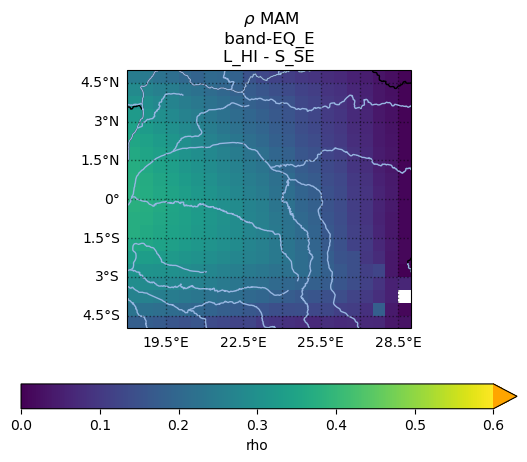

<Figure size 640x480 with 0 Axes>

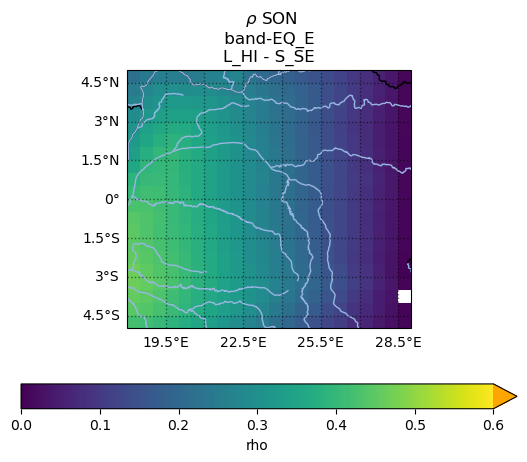

<Figure size 640x480 with 0 Axes>

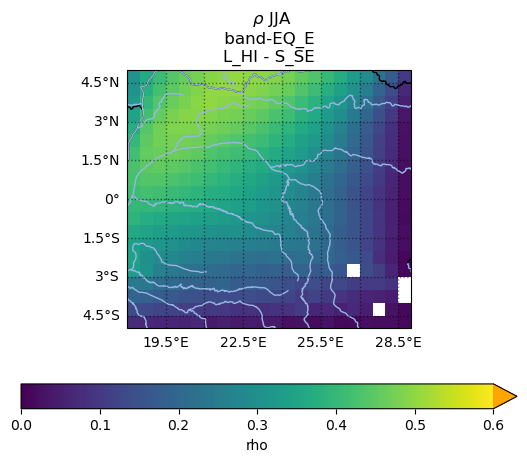

<Figure size 640x480 with 0 Axes>

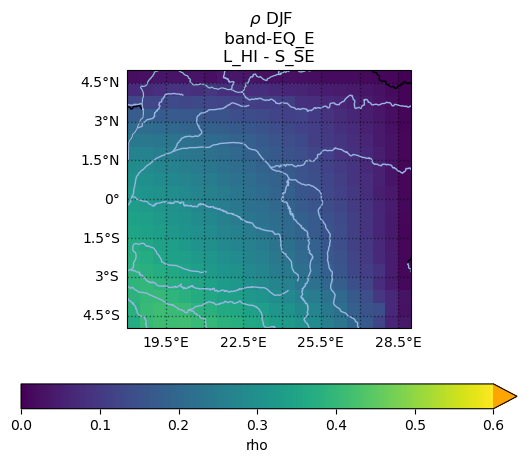

<Figure size 640x480 with 0 Axes>

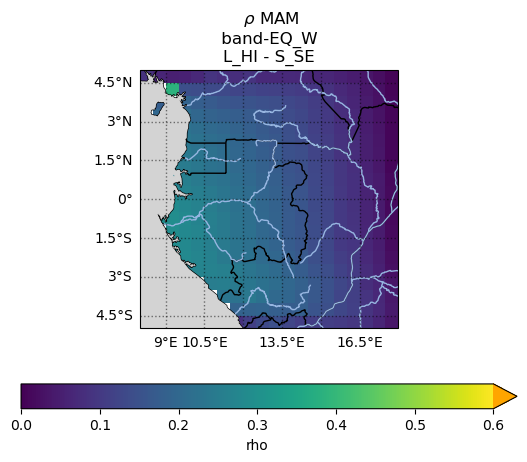

<Figure size 640x480 with 0 Axes>

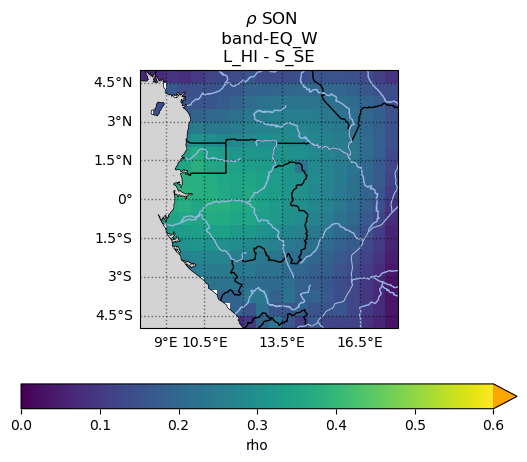

<Figure size 640x480 with 0 Axes>

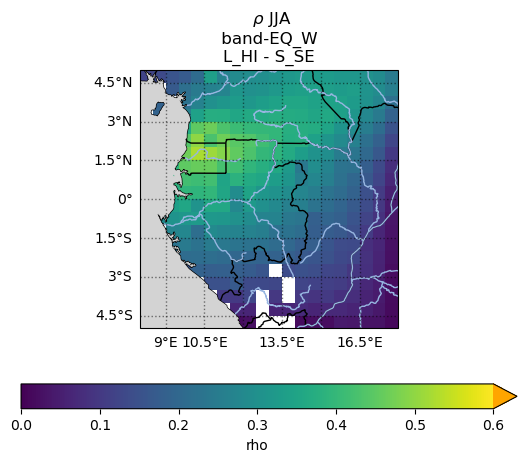

<Figure size 640x480 with 0 Axes>

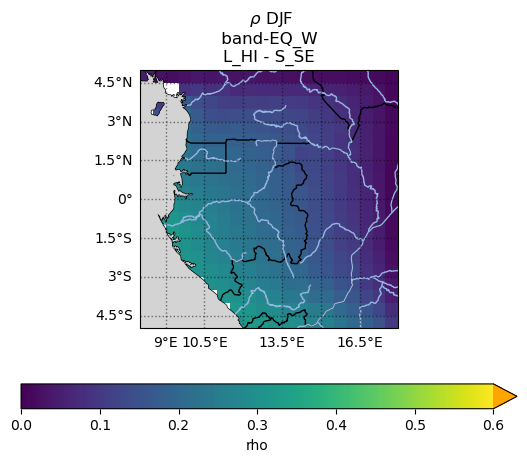

<Figure size 640x480 with 0 Axes>

In [4]:
#Seasonal average plots - average rotation
seas={'MAM':[3,4,5],'SON':[9,10,11],'JJA':[6,7,8],'DJF':[1,2,12]}
for B in ['EQ_E','EQ_W']:
    for S in seas:
        rho_plot = rho_xarr[B]['rho'].mean('rot') 
        seas_rho = rho_plot.where(rho_plot['time.month'].isin(seas[S]),drop=True).mean('time')
        #seas_rho = rho_plot.where(rho_plot['time.month']==M,drop=True).mean('time')
        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
        ax.coastlines()
        ax.add_feature(cartopy.feature.BORDERS)
        ax.add_feature(cartopy.feature.RIVERS)
        ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
        cmap=plt.cm.viridis
        cmap.set_extremes(over='orange')
        collection = seas_rho.plot.pcolormesh(vmin=0.0,vmax=0.6,
                                                        #levels=13,
                                                        ax=ax,extend='max',cmap=cmap,
                                                        cbar_kwargs={"location":"bottom"} )
        ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
        ax.set_title(" $\\rho$"+" "+S+"\n band-"+B+" \n"+L_NAME+" - "+S_NAME)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
              linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
        gl.top_labels = False
        gl.right_labels = False
        plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_rho_"+S+"_"+B+"rotmean.png")
        plt.show()
        plt.clf()
            
            
        